# **Machine Learning Task: HR Attrition Prediction (Classification)**

**Problem Statement**

Employee attrition is a critical issue for organizations, leading to increased hiring costs,
productivity loss, and reduced employee morale.

In this project, the goal is to build a **Machine Learning classification model** that predicts
whether an employee will leave the company (Attrition: Yes/No) based on features such as:

● Age

● Salary

● Job Role

● Job Satisfaction

● Work Experience

● Overtime

● Work-Life Balance

● Department

Students are required to analyze the dataset, preprocess the data, perform feature engineering,
train multiple classification models, and evaluate their performance to identify the best model for
predicting employee attrition.

**Objective**

The objective of this task is to:

● Understand and explore the HR dataset

● Perform data preprocessing (missing values, duplicates, outliers)

● Conduct Exploratory Data Analysis (EDA)

● Apply encoding and feature scaling

● Train multiple classification algorithms

● Evaluate models using classification metrics

● Perform cross-validation and hyperparameter tuning

● Select the best-performing model

The main goal is to predict whether an employee will leave the company (Attrition: Yes/No) using machine learning techniques. This helps organizations reduce employee turnover and improve retention strategies.

**Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# XGBoost
from xgboost import XGBClassifier

**Load Dataset**

In [ ]:
df = pd.read_csv("HR-Employee-Attrition.csv")

In [ ]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


**Basic Dataset Checks**

**Shape**

In [ ]:
df.shape

(1470, 35)

**Columns**

In [ ]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

**Data types**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

**Summary statistics**

In [ ]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


**Handle Missing Values**

In [ ]:
print(df.isnull().sum())
df = df.dropna()  # or fillna()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

**Remove Duplicates**

In [ ]:
df = df.drop_duplicates()

**Univariate Analysis**

**Distribution of numerical features**

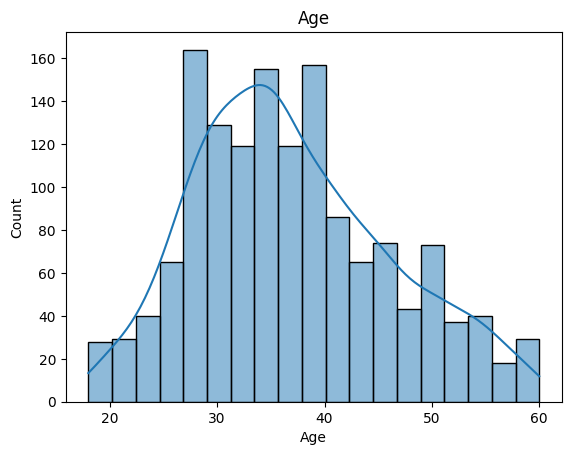

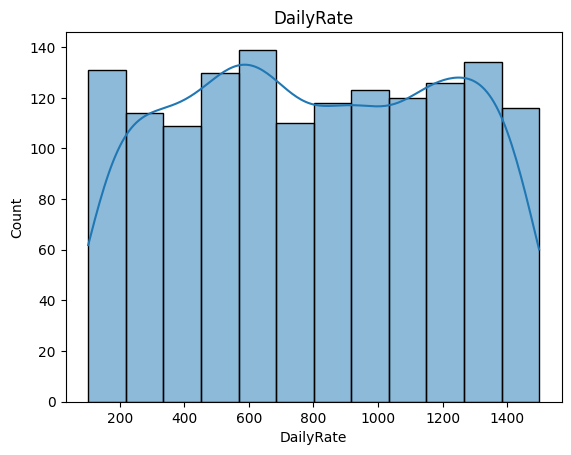

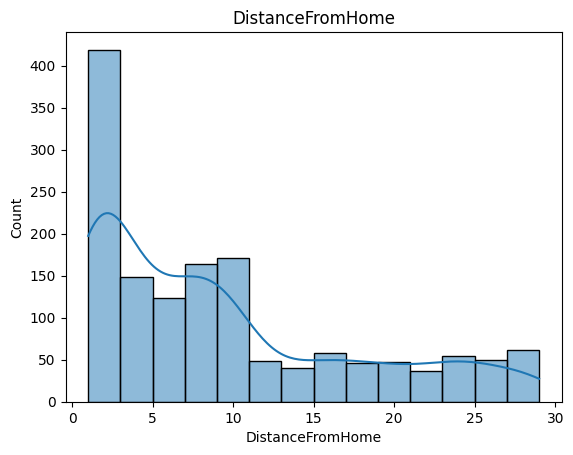

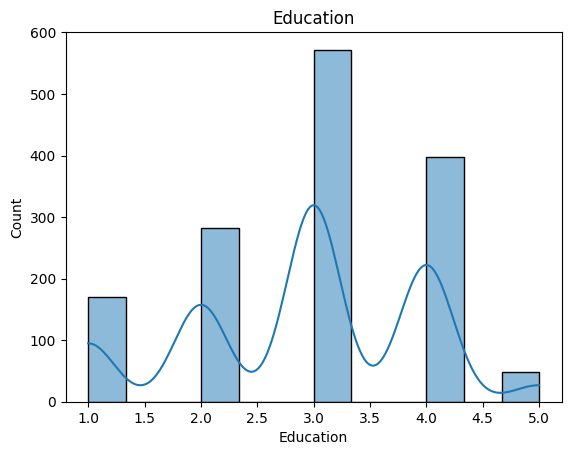

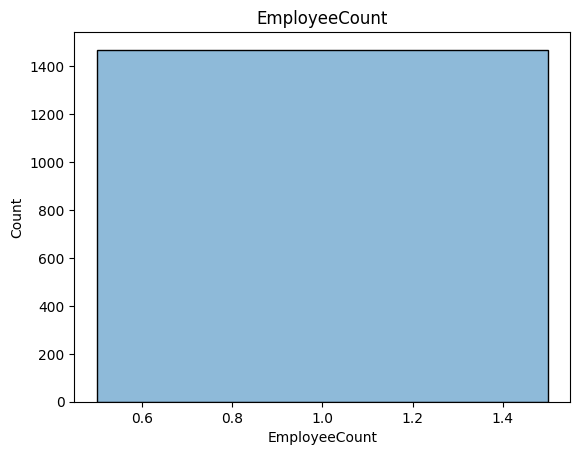

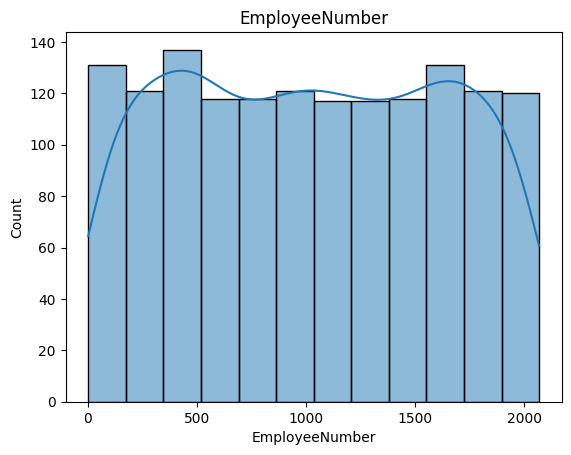

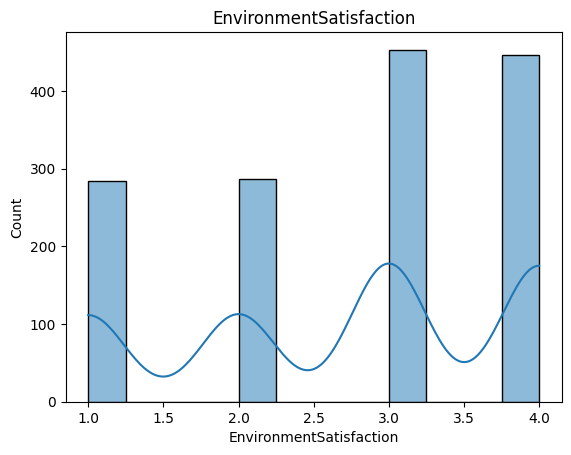

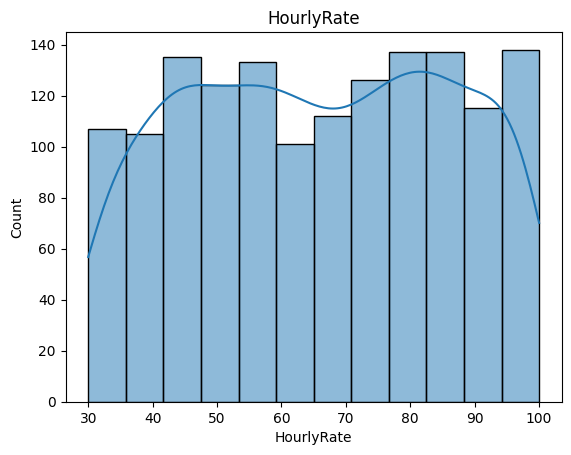

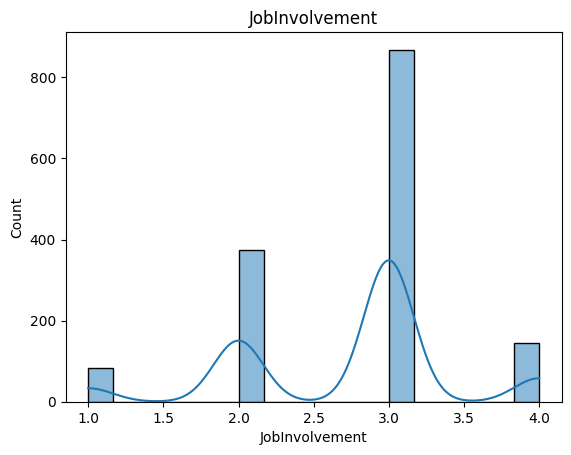

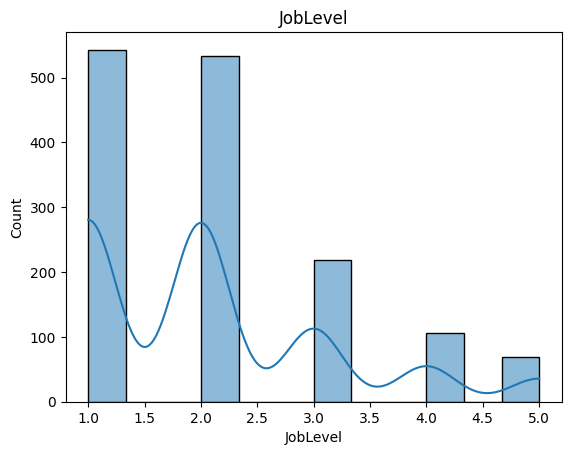

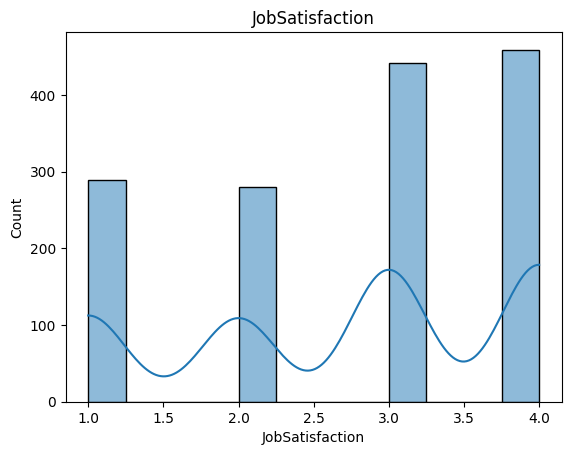

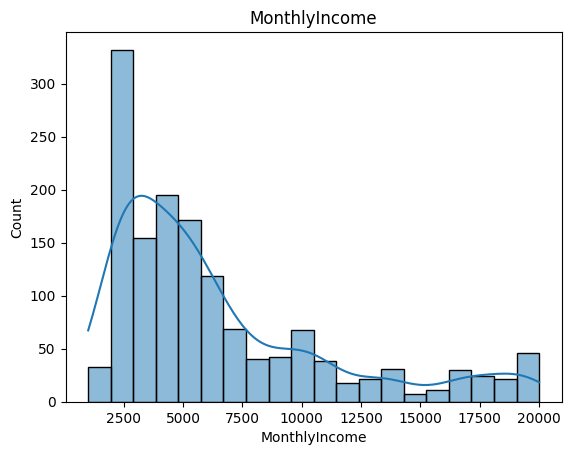

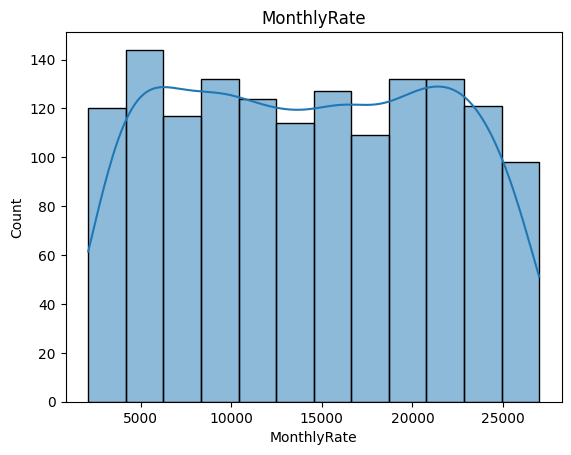

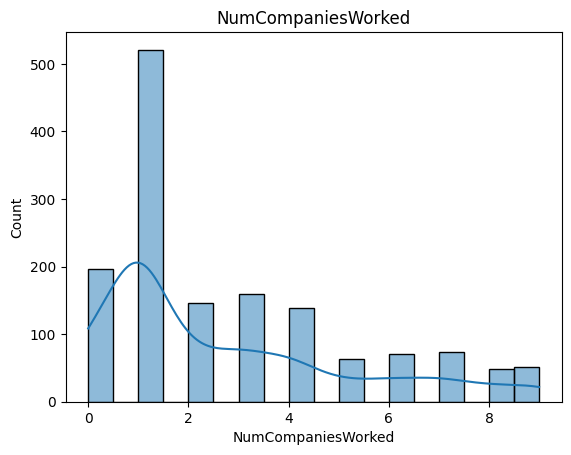

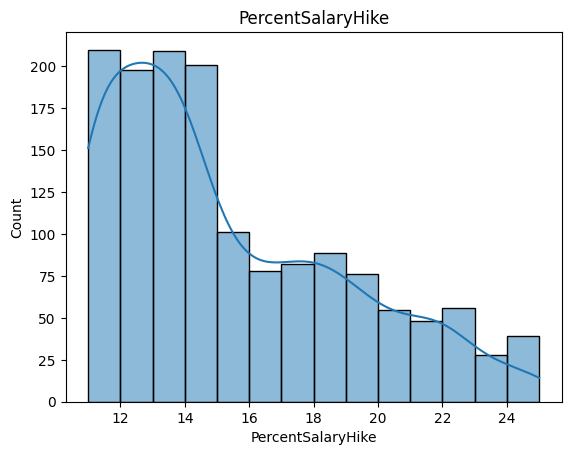

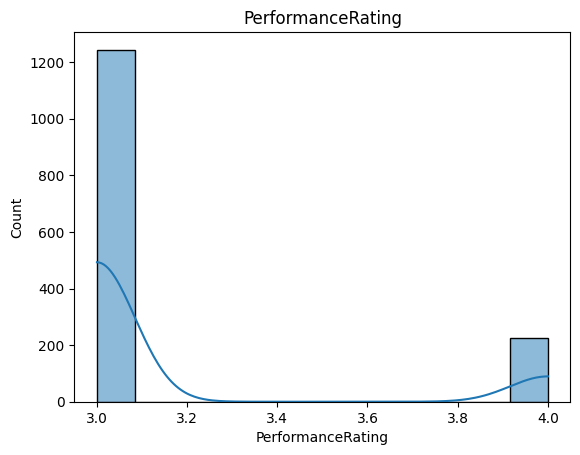

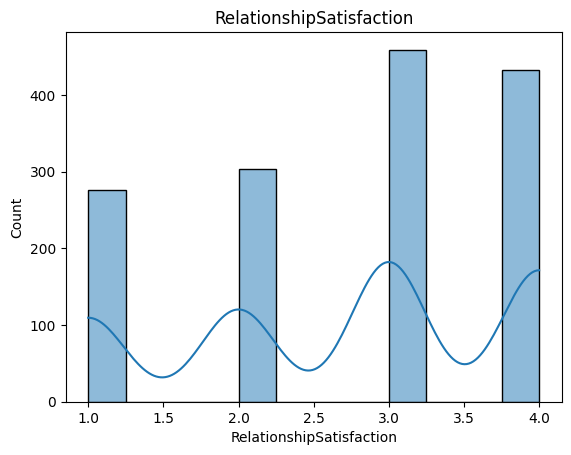

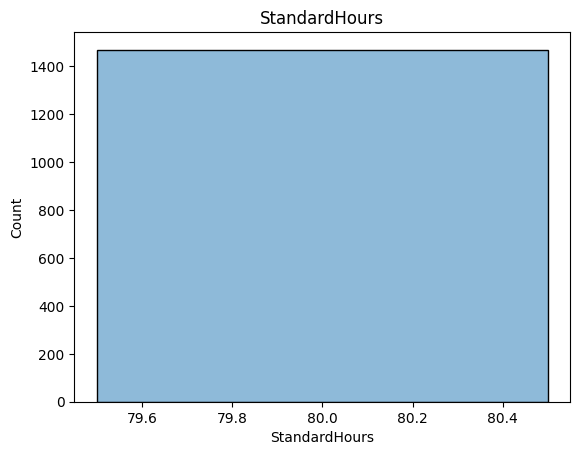

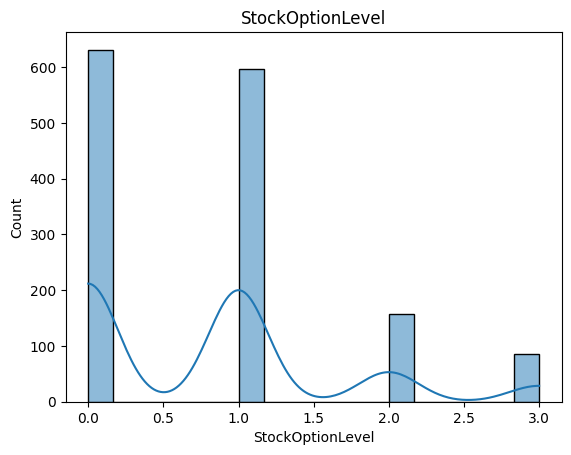

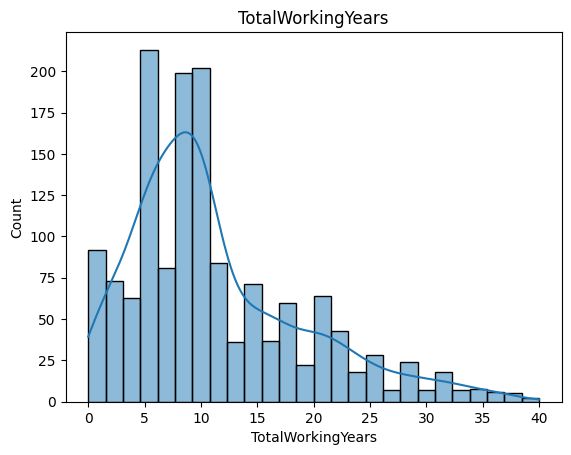

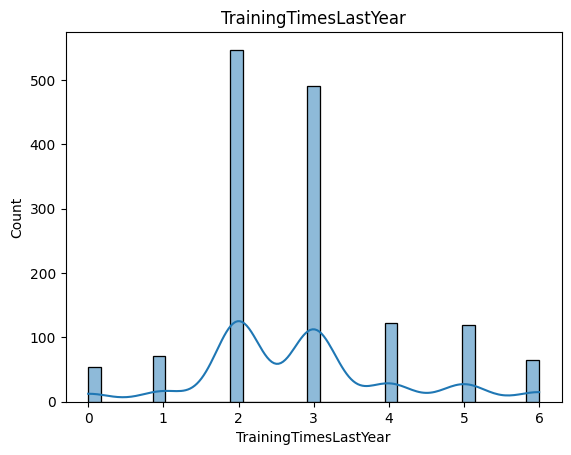

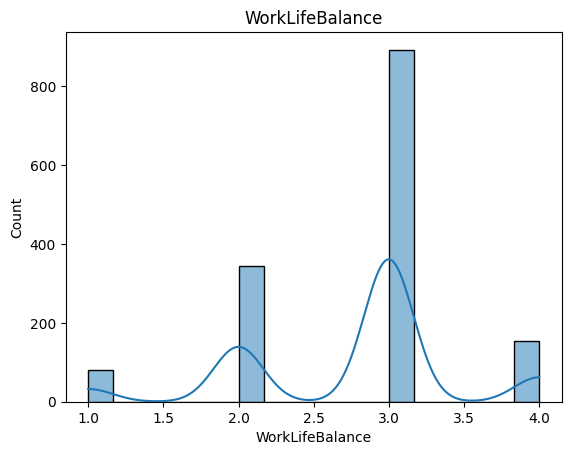

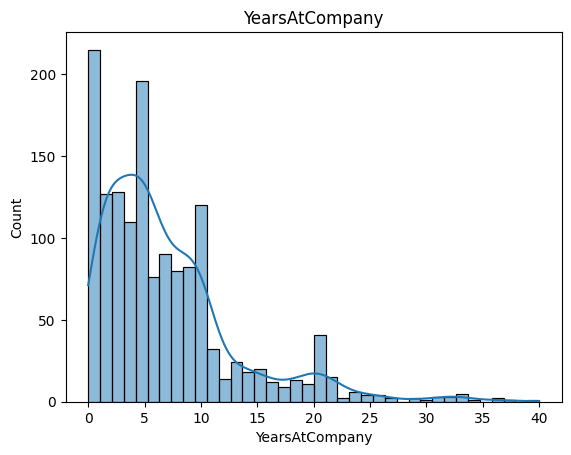

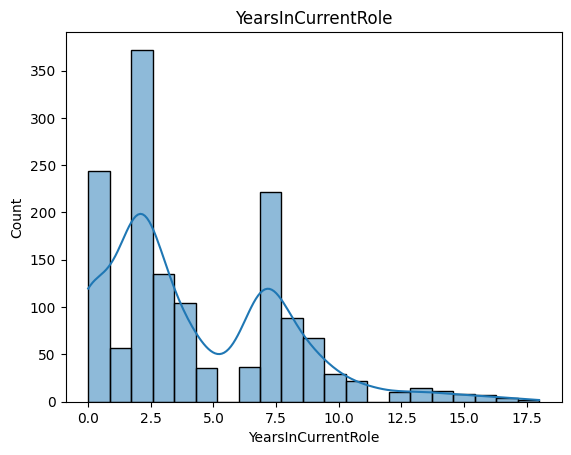

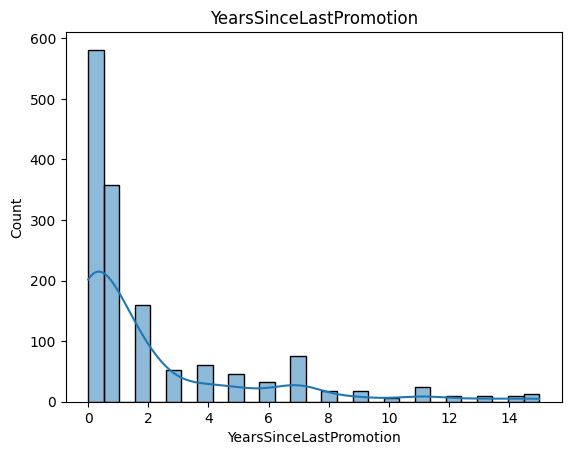

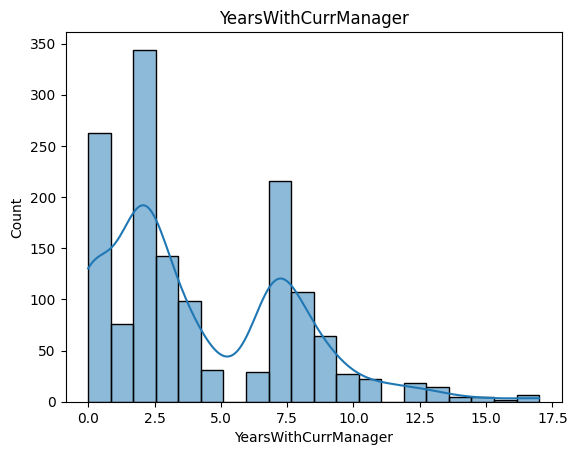

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

**Count plots for categorical features**

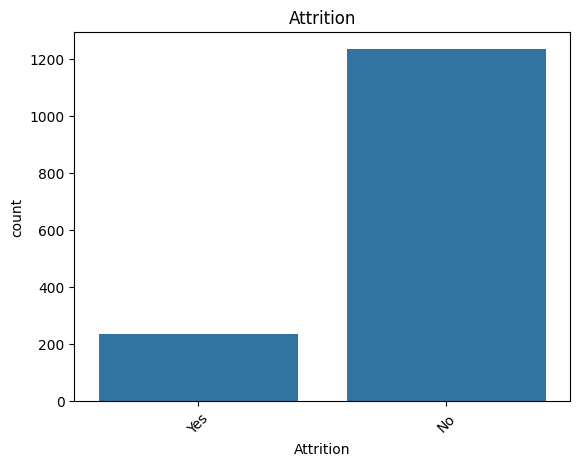

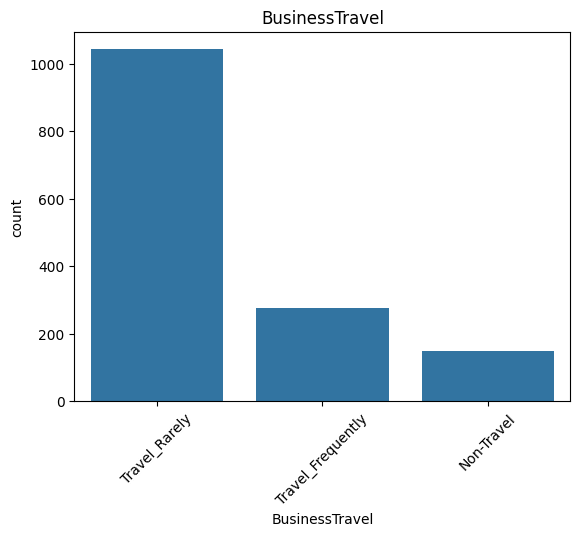

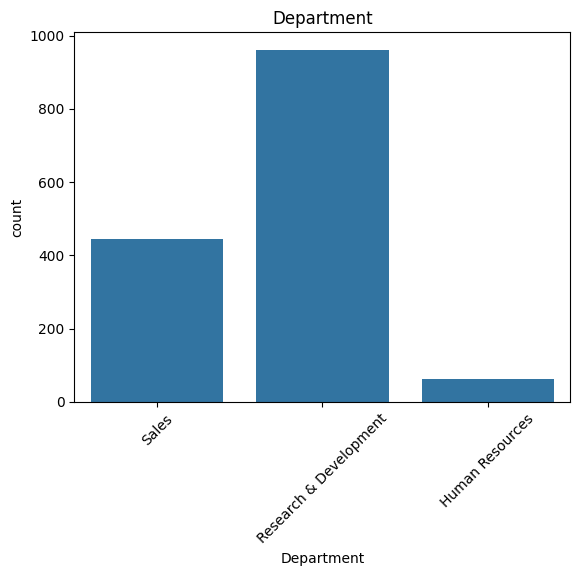

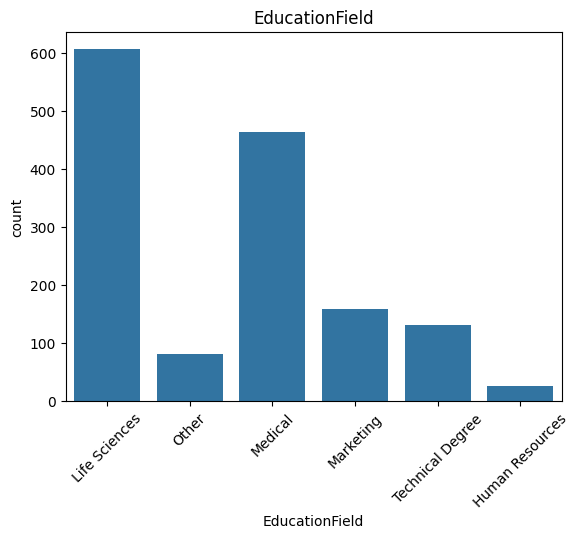

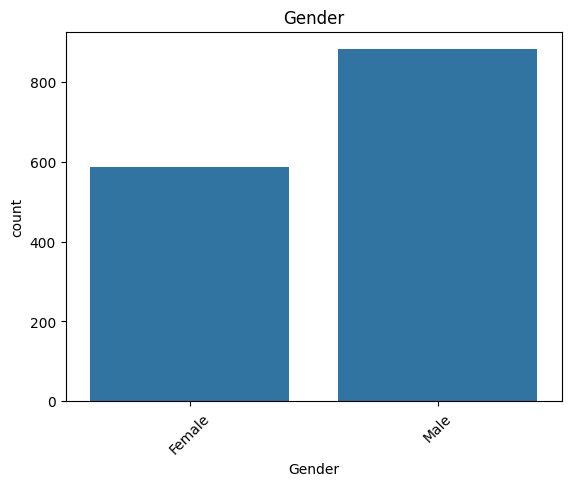

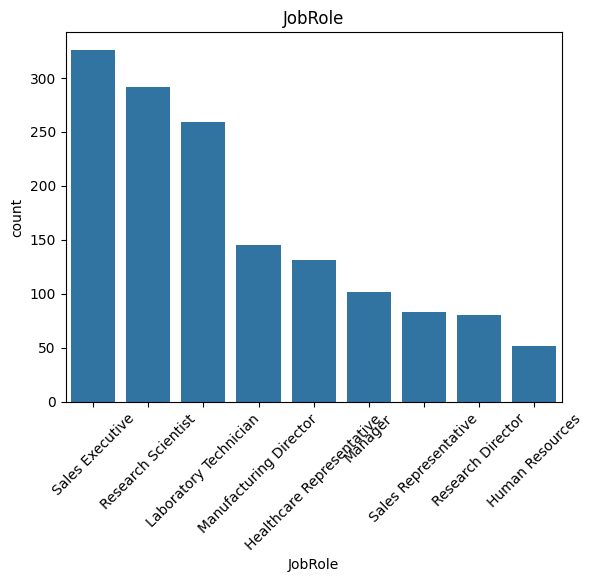

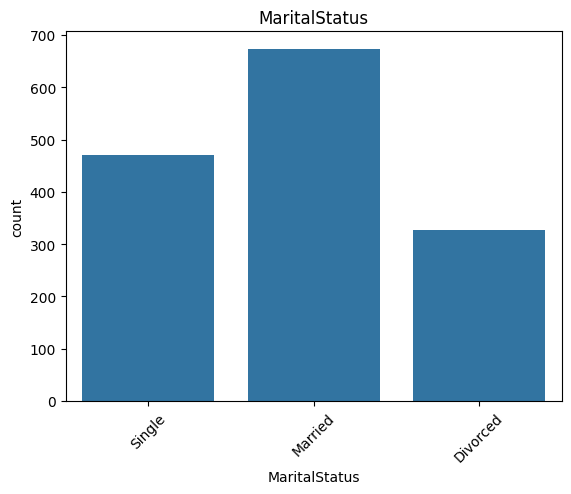

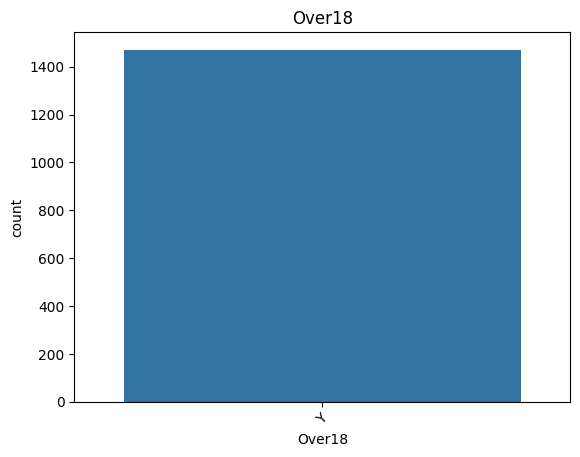

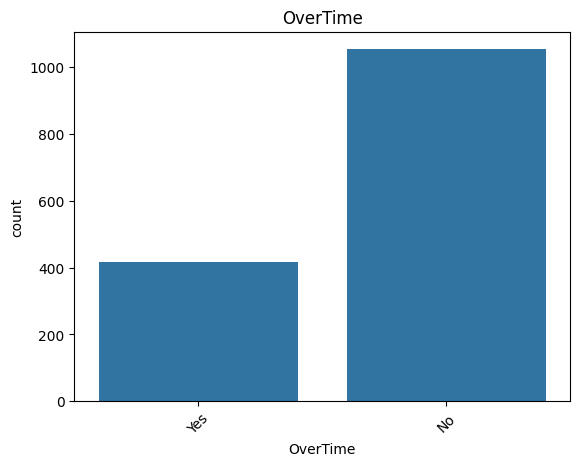

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

**Bivariate Analysis**

**Attrition vs Categorical Features**

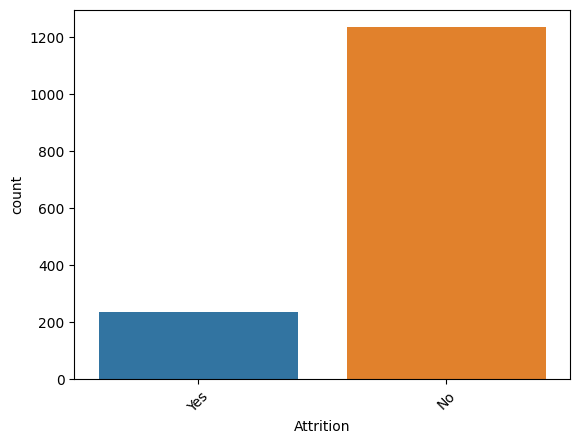

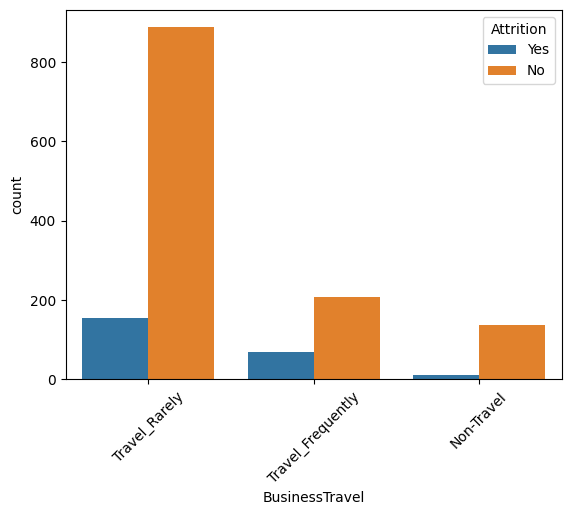

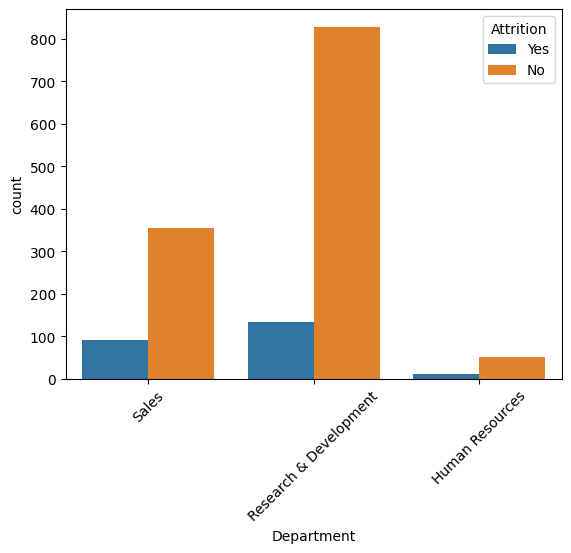

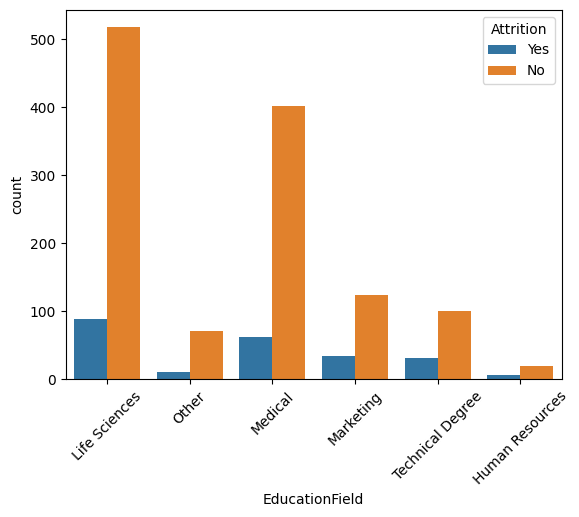

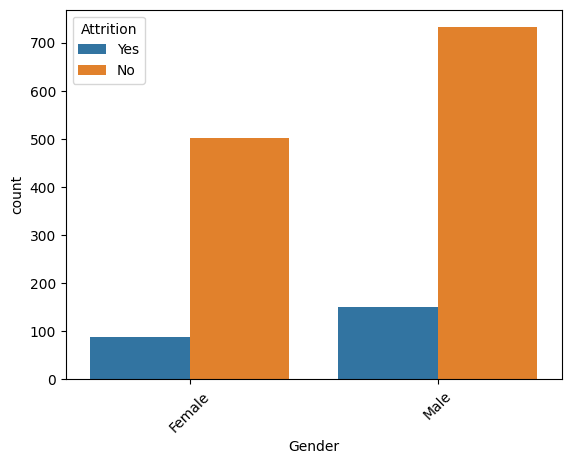

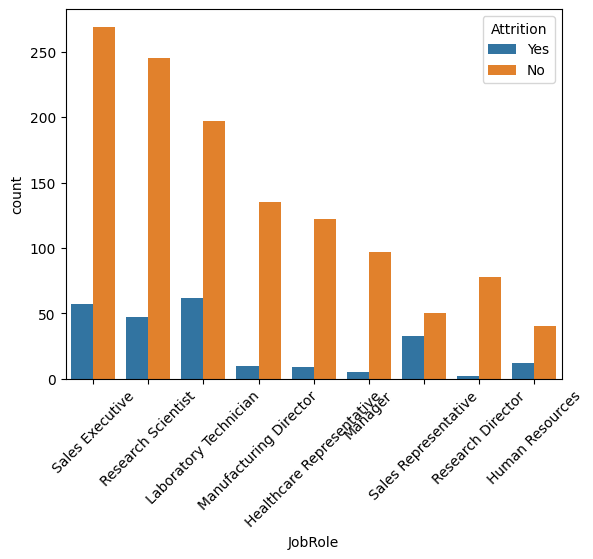

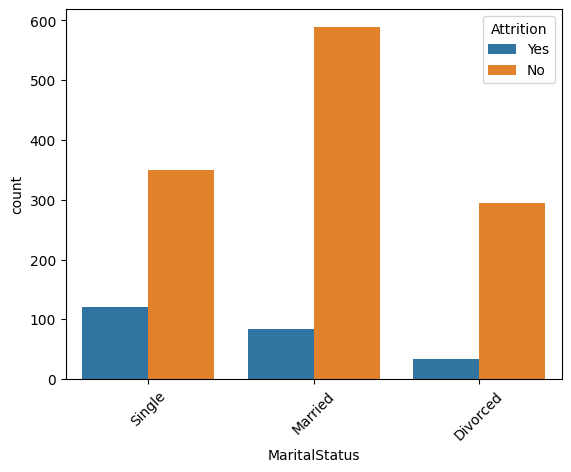

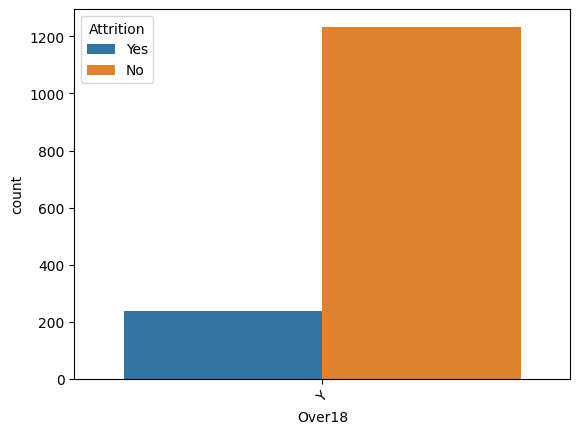

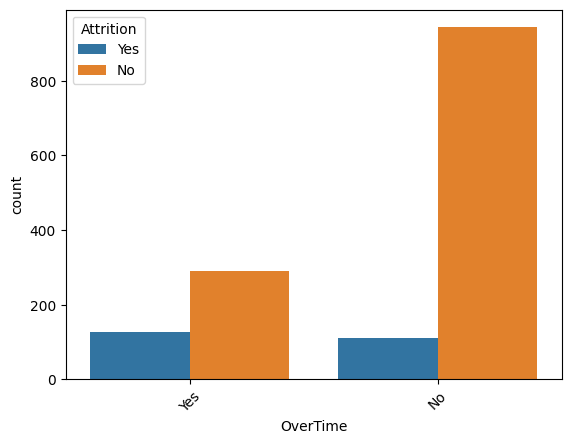

In [ ]:
for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, hue="Attrition", data=df)
    plt.xticks(rotation=45)
    plt.show()

**Attrition vs Numerical Features**

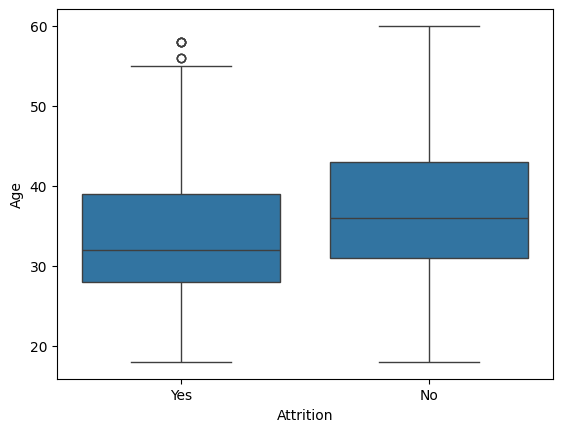

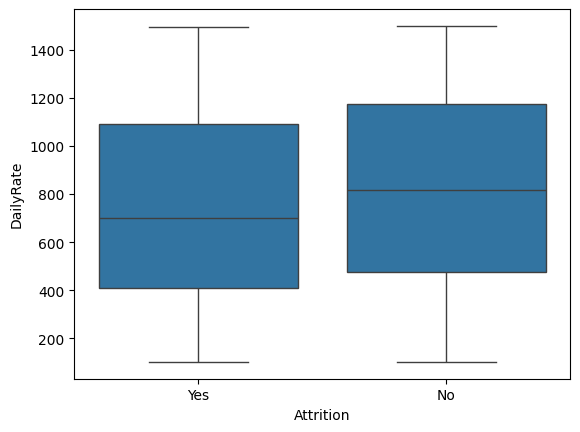

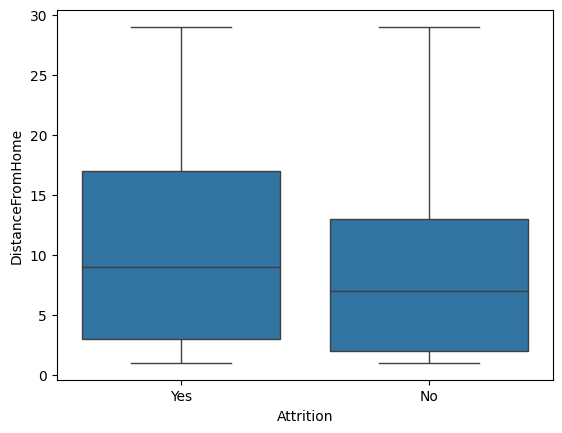

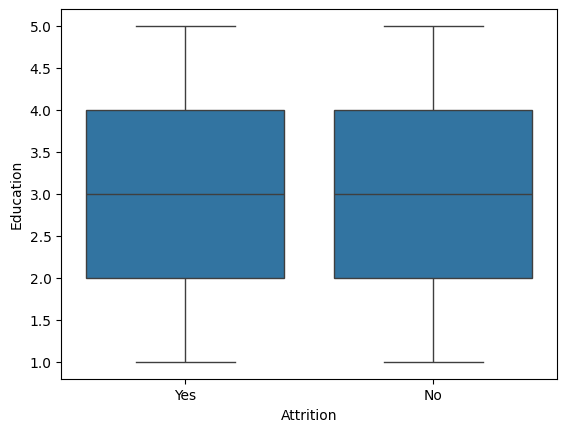

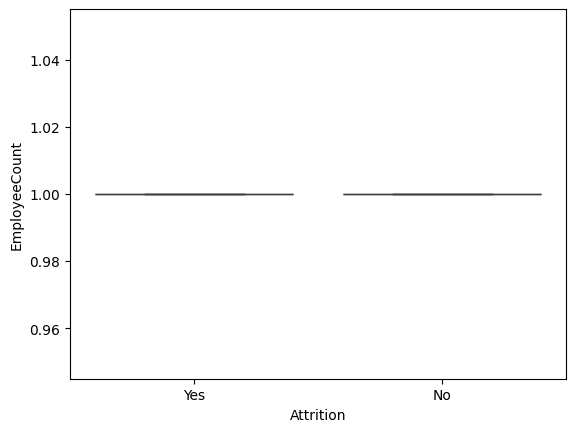

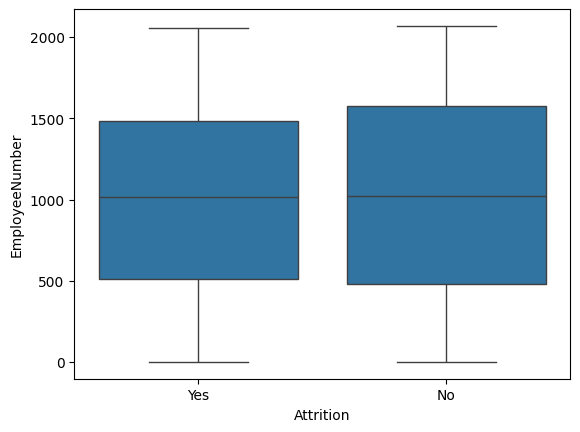

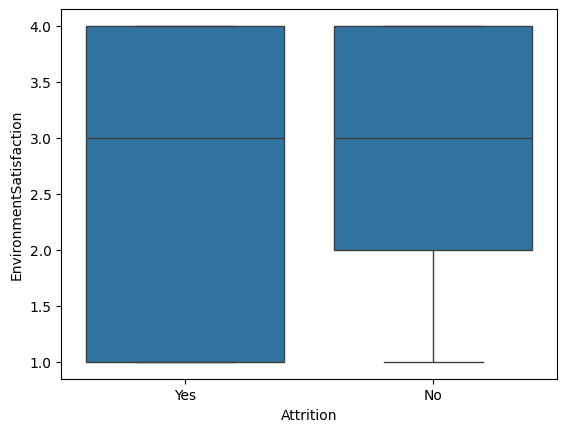

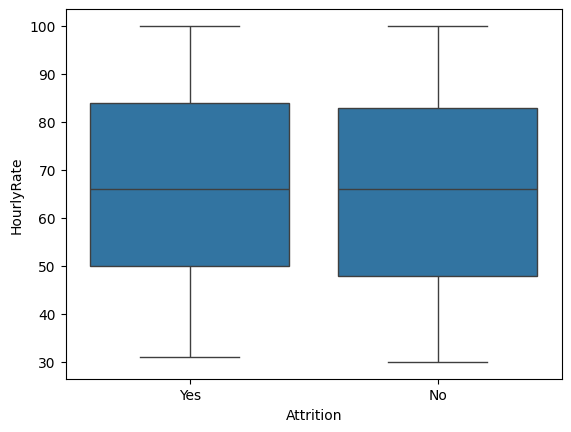

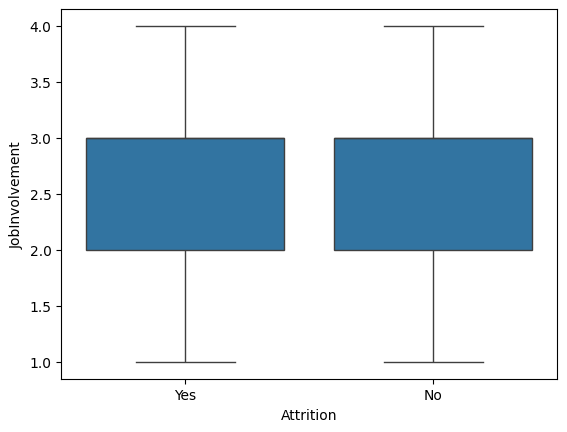

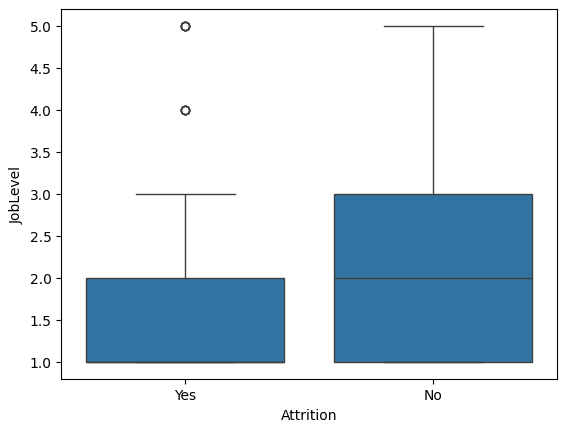

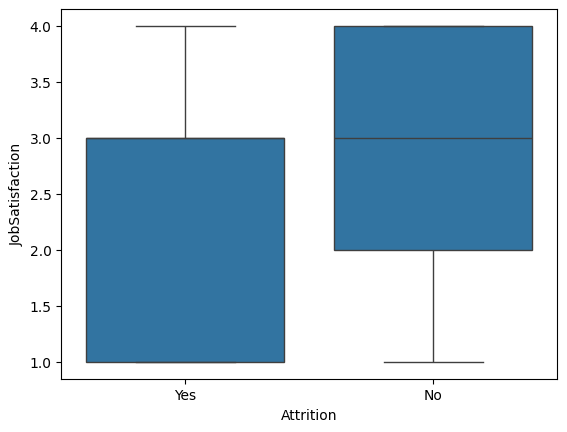

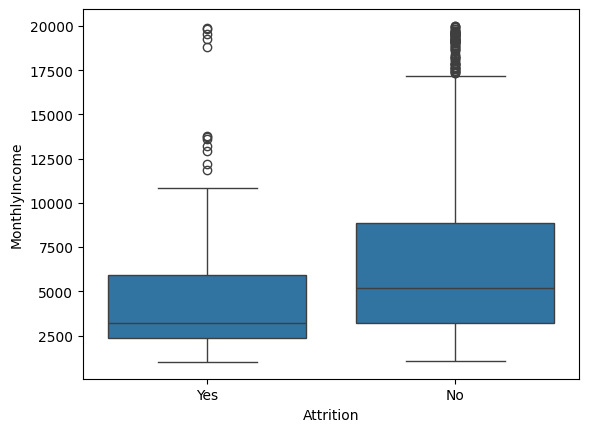

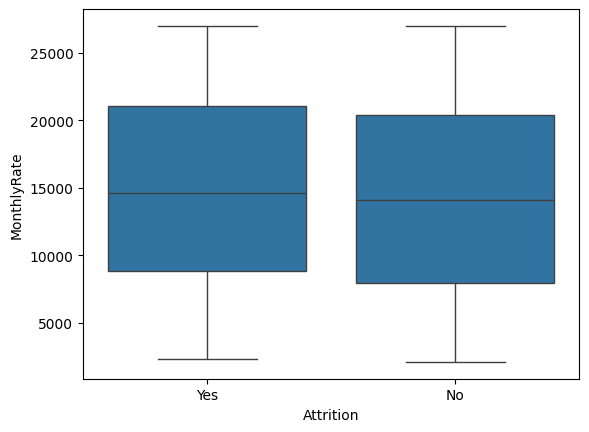

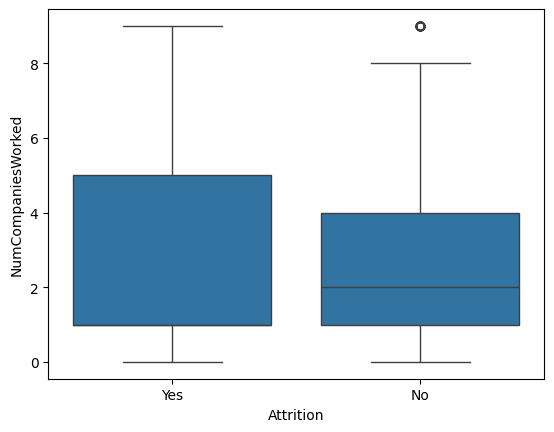

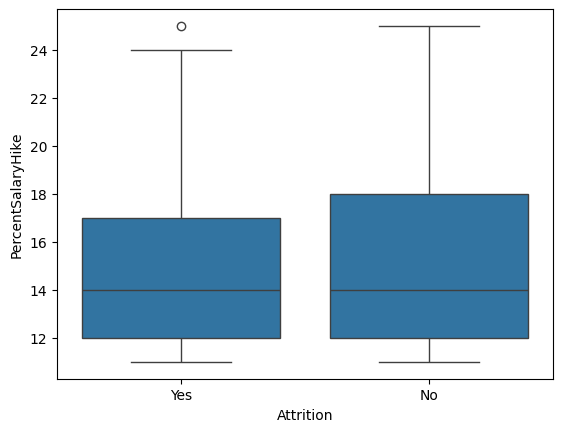

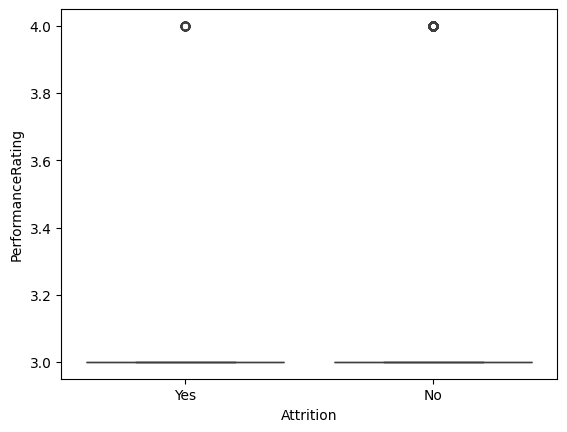

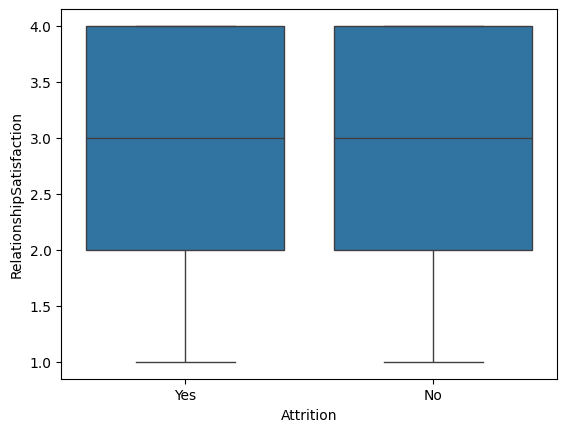

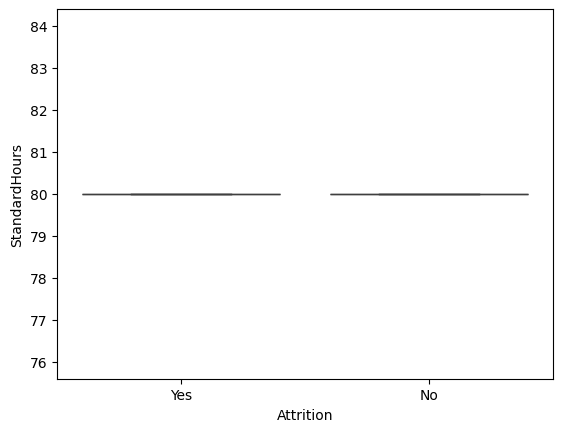

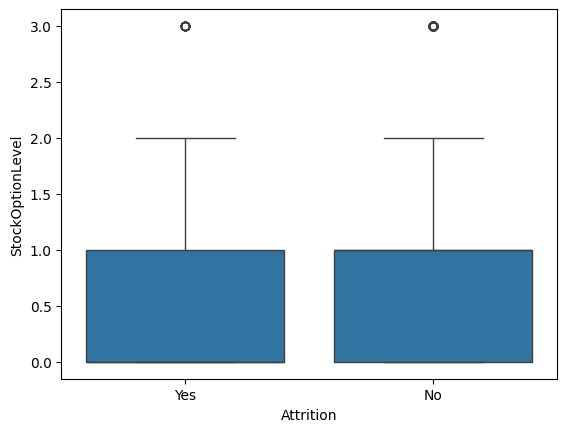

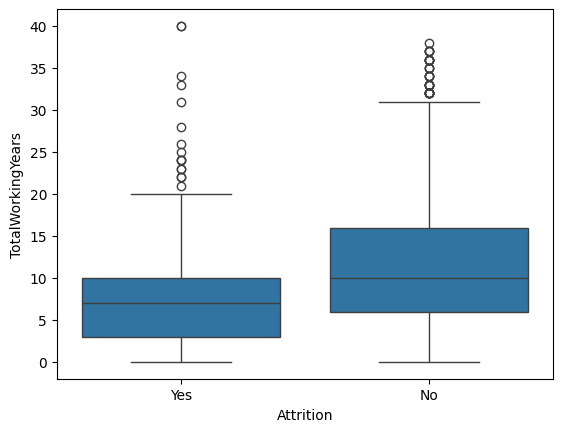

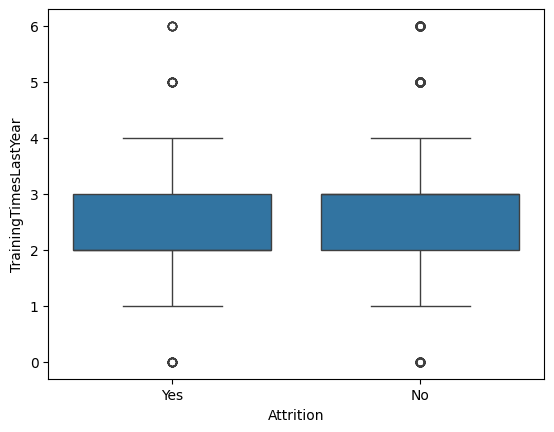

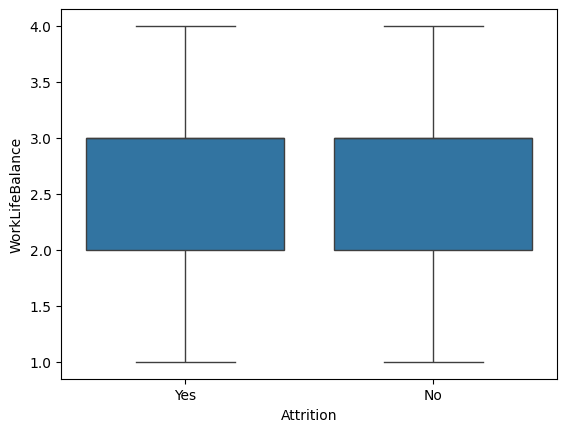

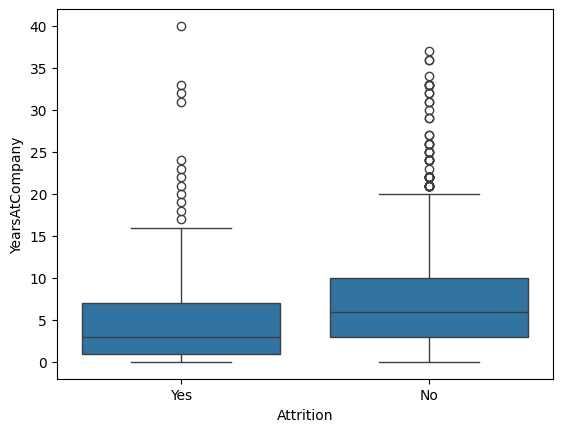

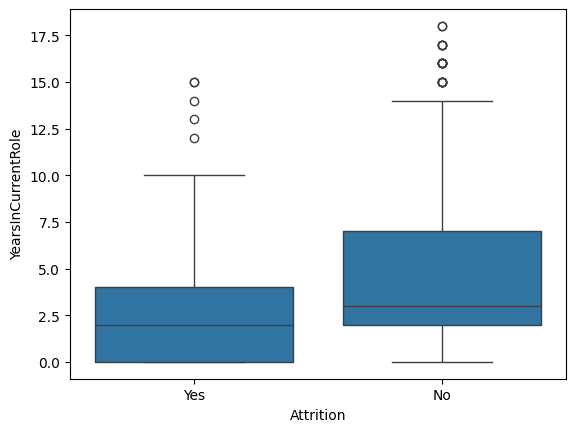

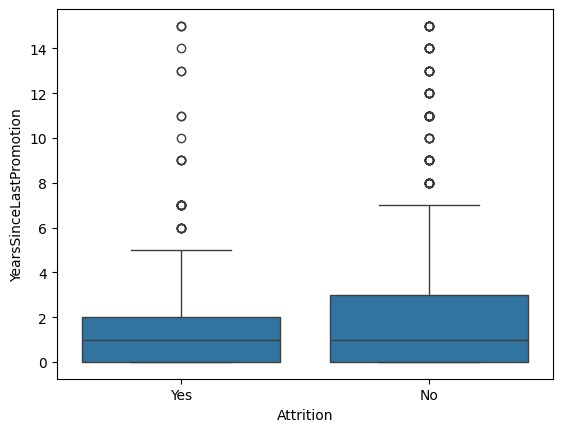

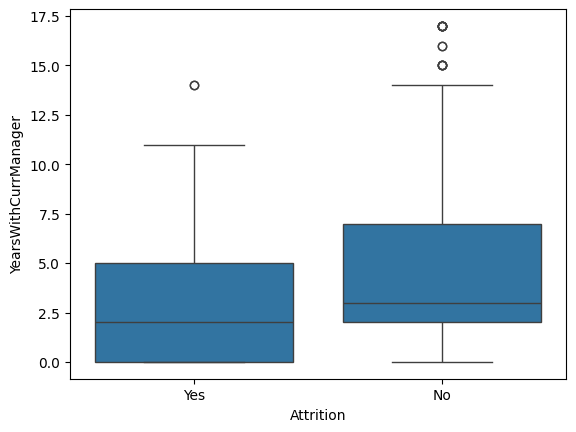

In [ ]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x="Attrition", y=col, data=df)
    plt.show()

**Correlation Heatmap**

Now that the 'Attrition' column is numerical, we can generate the correlation heatmap:

In [ ]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
print("Attrition column converted to numerical:")
display(df['Attrition'].value_counts())

Attrition column converted to numerical:


,count
Attrition,
0,1233
1,237


### **Outlier Detection**

We will use the Interquartile Range (IQR) method to detect outliers in numerical columns. Outliers are typically defined as data points that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`.

Column 'Age' has no significant outliers.
Column 'Attrition' has 237 outliers.


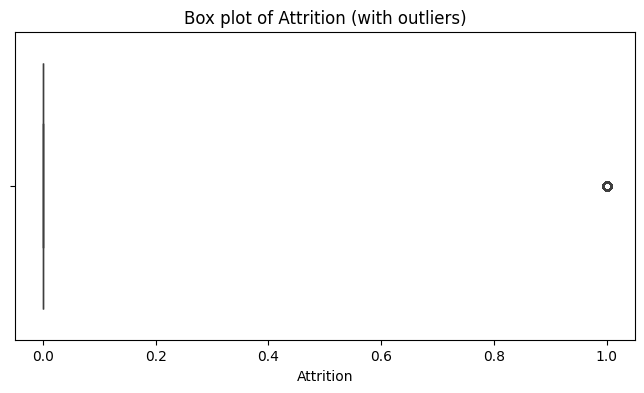

Column 'DailyRate' has no significant outliers.
Column 'DistanceFromHome' has no significant outliers.
Column 'Education' has no significant outliers.
Column 'EmployeeCount' has no significant outliers.
Column 'EmployeeNumber' has no significant outliers.
Column 'EnvironmentSatisfaction' has no significant outliers.
Column 'HourlyRate' has no significant outliers.
Column 'JobInvolvement' has no significant outliers.
Column 'JobLevel' has no significant outliers.
Column 'JobSatisfaction' has no significant outliers.
Column 'MonthlyIncome' has 114 outliers.


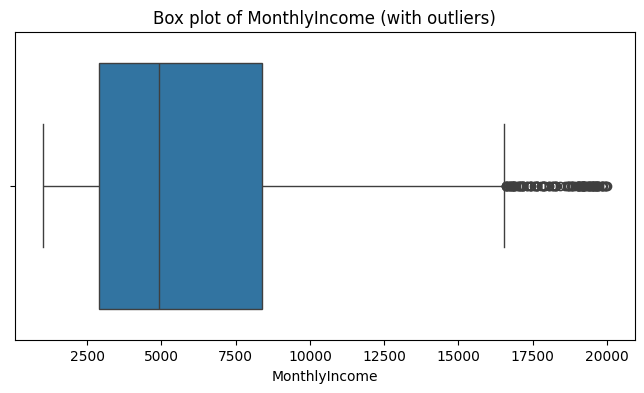

Column 'MonthlyRate' has no significant outliers.
Column 'NumCompaniesWorked' has 52 outliers.


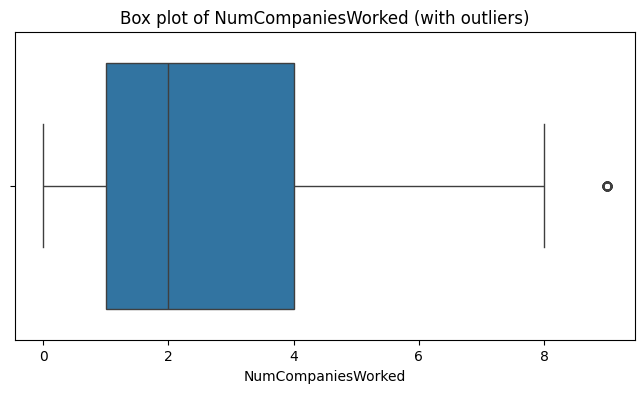

Column 'PercentSalaryHike' has no significant outliers.
Column 'PerformanceRating' has 226 outliers.


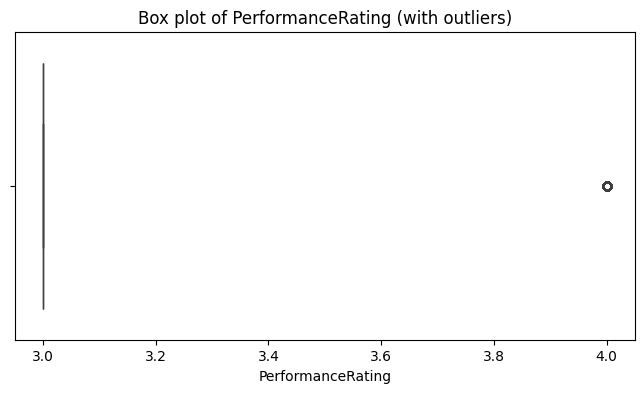

Column 'RelationshipSatisfaction' has no significant outliers.
Column 'StandardHours' has no significant outliers.
Column 'StockOptionLevel' has 85 outliers.


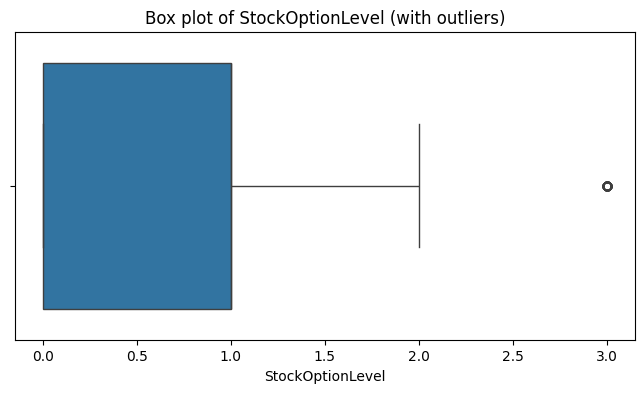

Column 'TotalWorkingYears' has 63 outliers.


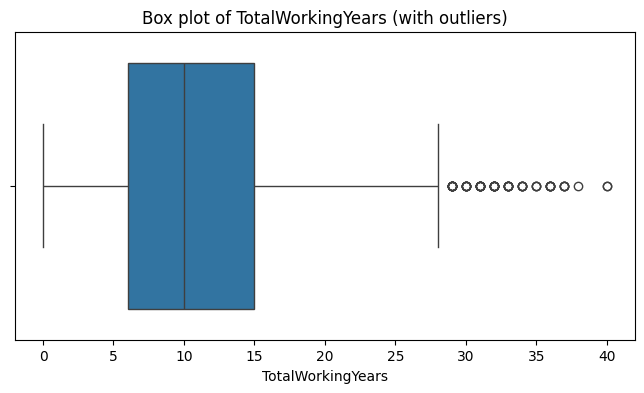

Column 'TrainingTimesLastYear' has 238 outliers.


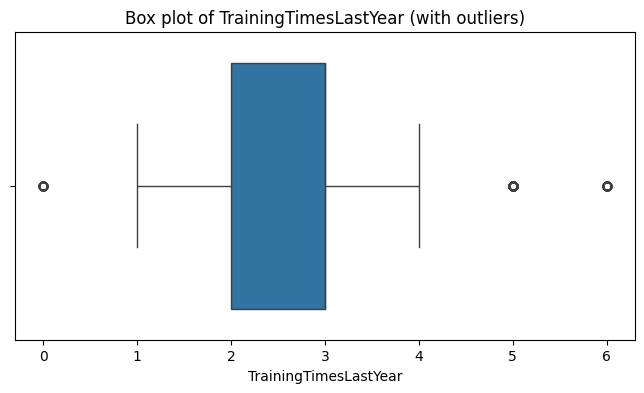

Column 'WorkLifeBalance' has no significant outliers.
Column 'YearsAtCompany' has 104 outliers.


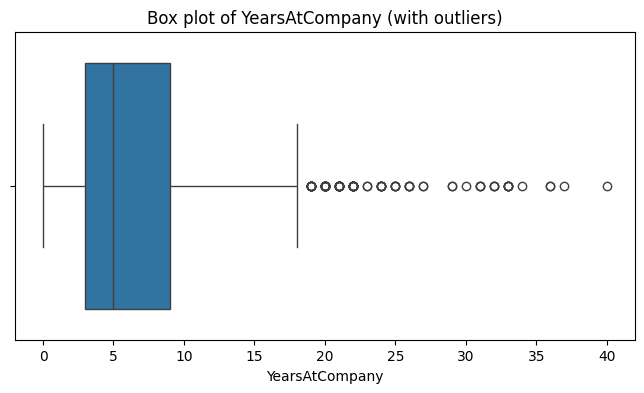

Column 'YearsInCurrentRole' has 21 outliers.


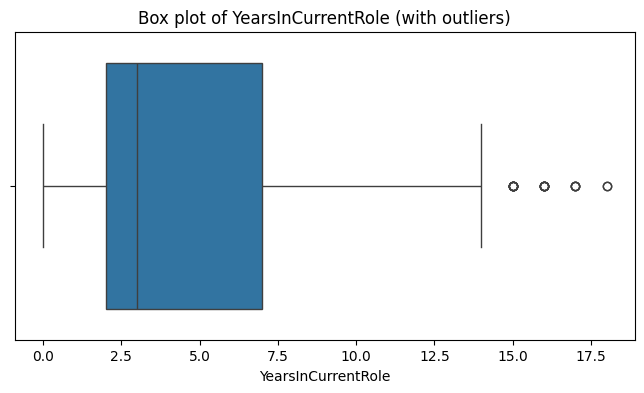

Column 'YearsSinceLastPromotion' has 107 outliers.


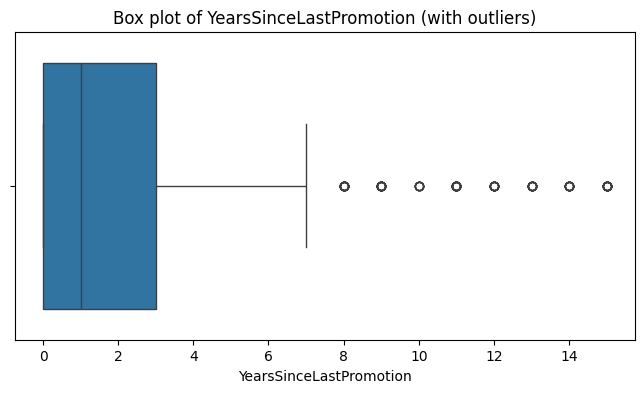

Column 'YearsWithCurrManager' has 14 outliers.


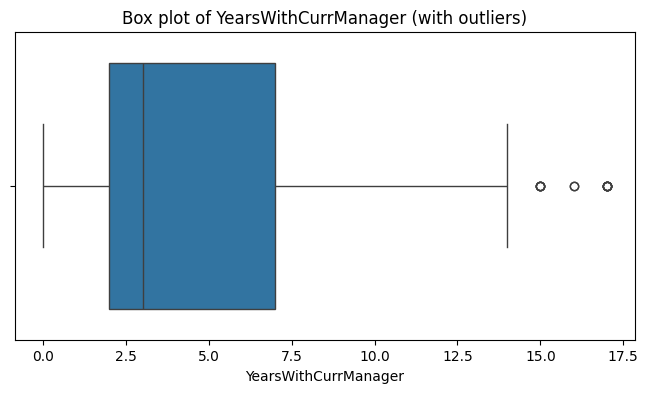

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if not outliers.empty:
        print(f"Column '{col}' has {len(outliers)} outliers.")
        # Optional: Visualize outliers using a box plot
        plt.figure(figsize=(8, 4))
        sns.boxplot(x=df[col])
        plt.title(f"Box plot of {col} (with outliers)")
        plt.show()
    else:
        print(f"Column '{col}' has no significant outliers.")

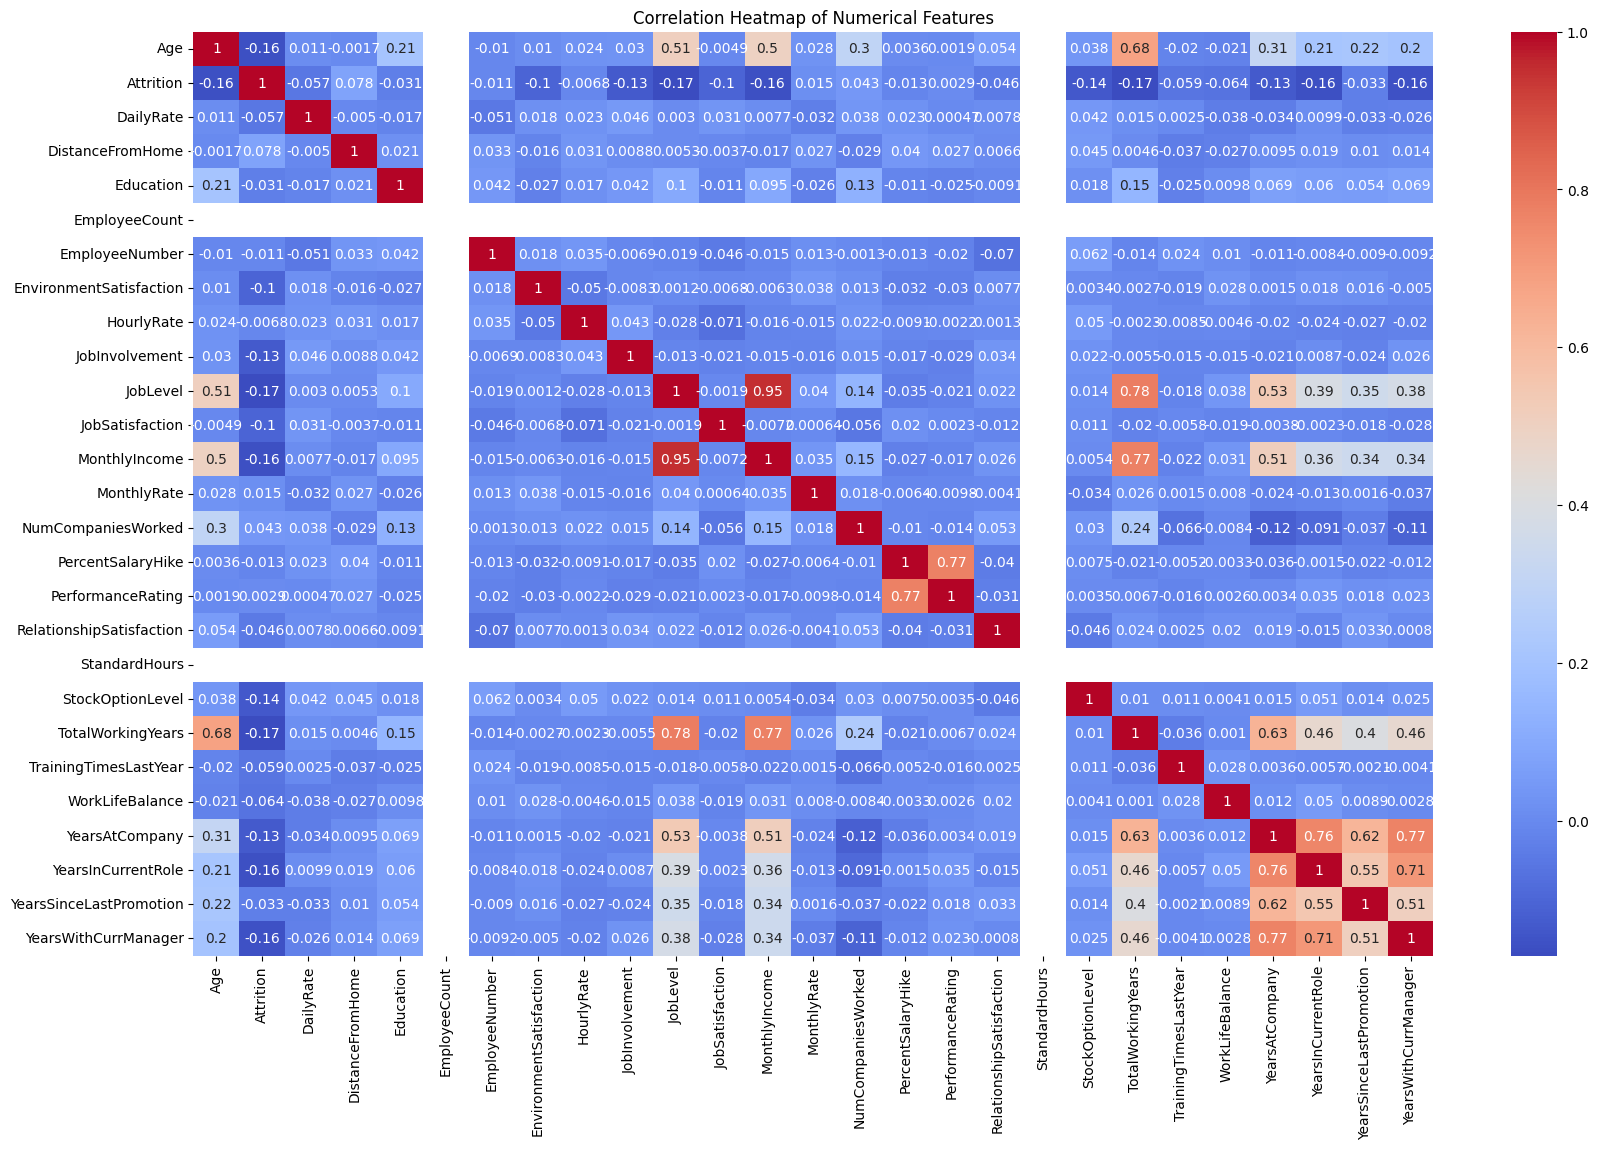

In [ ]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Detect & Handle Outliers**

In [ ]:
# Original aggressive outlier removal logic is commented out to prevent data loss
# and preserve the minority class for attrition prediction.
# num_cols_for_outlier_removal = [col for col in num_cols if col != 'Attrition']
#
# for col in num_cols_for_outlier_removal:
#     Q1 = df[col].quantile(0.25)
#     Q3 = df[col].quantile(0.75)
#     IQR = Q3 - Q1
#
#     lower = Q1 - 1.5*IQR
#     upper = Q3 + 1.5*IQR
#
#     df = df[(df[col] >= lower) & (df[col] <= upper)]
print("Aggressive outlier removal has been disabled to preserve the target classes.")

Aggressive outlier removal has been disabled to preserve the target classes.


**Encoding**

**Label Encoding**

In [ ]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

**Scaling**

In [ ]:
scaler = StandardScaler()
# Ensure 'Attrition' is not included in numerical columns for scaling
current_num_cols = df.select_dtypes(include=np.number).columns.tolist()
features_to_scale = [col for col in current_num_cols if col != 'Attrition']
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

**Separate Features & Target**

In [ ]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Balance Data (SMOTE)**

In [ ]:
if y_train.nunique() > 1:
    smote = SMOTE(random_state=42)
    X_train, y_train = smote.fit_resample(X_train, y_train)
    print("SMOTE applied: Training data balanced.")
else:
    print("SMOTE skipped: y_train contains only one class after preprocessing and outlier removal. Review previous data filtering steps.")
    print("Value counts of y_train:")
    display(y_train.value_counts())

SMOTE applied: Training data balanced.


Train Models

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True)
}

**Evaluate Models**

In [ ]:
results = []

for name, model in models.items():
    # Check if y_train has more than one class before fitting
    if y_train.nunique() < 2:
        print(f"\nSkipping {name}: y_train has only one class. Cannot train model.")
        continue

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Check if y_test contains only one class before computing ROC-AUC
    if y_test.nunique() > 1:
        roc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    else:
        roc = "N/A (y_test contains only one class)"

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc)
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    results.append([name, acc, prec, rec, f1, roc])


Logistic Regression
Accuracy: 0.7380952380952381
Precision: 0.29347826086956524
Recall: 0.6923076923076923
F1 Score: 0.4122137404580153
ROC-AUC: 0.7484162895927602
Confusion Matrix:
 [[190  65]
 [ 12  27]]

Decision Tree
Accuracy: 0.7619047619047619
Precision: 0.2459016393442623
Recall: 0.38461538461538464
F1 Score: 0.3
ROC-AUC: 0.6021116138763197
Confusion Matrix:
 [[209  46]
 [ 24  15]]

Random Forest
Accuracy: 0.8707482993197279
Precision: 0.5333333333333333
Recall: 0.20512820512820512
F1 Score: 0.2962962962962963
ROC-AUC: 0.7414278531925591
Confusion Matrix:
 [[248   7]
 [ 31   8]]

Gradient Boosting
Accuracy: 0.8707482993197279
Precision: 0.5238095238095238
Recall: 0.28205128205128205
F1 Score: 0.36666666666666664
ROC-AUC: 0.783911513323278
Confusion Matrix:
 [[245  10]
 [ 28  11]]

XGBoost
Accuracy: 0.8605442176870748
Precision: 0.4642857142857143
Recall: 0.3333333333333333
F1 Score: 0.3880597014925373
ROC-AUC: 0.7996983408748115
Confusion Matrix:
 [[240  15]
 [ 26  13]]

KNN
Ac

**Cross Validation**

In [ ]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Score:", scores.mean())

Logistic Regression CV Score: 0.8700680272108843
Decision Tree CV Score: 0.7829931972789115
Random Forest CV Score: 0.85578231292517
Gradient Boosting CV Score: 0.8625850340136054
XGBoost CV Score: 0.8598639455782312
KNN CV Score: 0.8408163265306122
SVM CV Score: 0.84421768707483


**Hyperparameter Tuning**

**GridSearchCV**

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


**RandomizedSearchCV**

In [ ]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 10)
}

rand = RandomizedSearchCV(RandomForestClassifier(), param_dist, cv=5)
rand.fit(X_train, y_train)

print("Best Params:", rand.best_params_)

Best Params: {'max_depth': 9, 'n_estimators': 190}


**Model Comparison**

In [ ]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1", "ROC-AUC"])
print(results_df.sort_values(by="F1", ascending=False))

                 Model  Accuracy  Precision    Recall        F1   ROC-AUC
6                  SVM  0.806122   0.350000  0.538462  0.424242  0.709100
0  Logistic Regression  0.738095   0.293478  0.692308  0.412214  0.748416
4              XGBoost  0.860544   0.464286  0.333333  0.388060  0.799698
3    Gradient Boosting  0.870748   0.523810  0.282051  0.366667  0.783912
1        Decision Tree  0.761905   0.245902  0.384615  0.300000  0.602112
2        Random Forest  0.870748   0.533333  0.205128  0.296296  0.741428
5                  KNN  0.615646   0.186441  0.564103  0.280255  0.618451


**Comparison Table**

| Model               | Accuracy | Precision | Recall    | F1 Score  | ROC-AUC   |
| ------------------- | -------- | --------- | --------- | --------- | --------- |
| **SVM**             | 0.806    | 0.35      | 0.538     | **0.424** | 0.709     |
| Logistic Regression | 0.738    | 0.293     | **0.692** | 0.412     | 0.748     |
| XGBoost             | 0.860    | 0.464     | 0.333     | 0.388     | **0.799** |
| Gradient Boosting   | 0.870    | 0.524     | 0.282     | 0.366     | 0.783     |
| Decision Tree       | 0.761    | 0.246     | 0.385     | 0.300     | 0.602     |
| Random Forest       | 0.870    | **0.533** | 0.205     | 0.296     | 0.741     |
| KNN                 | 0.615    | 0.186     | 0.564     | 0.280     | 0.618     |


**Best Model (Based on Metrics)**

**Selected Model: SVM (Support Vector Machine)**

 Why SVM?

→ Highest F1 Score (0.424)

 → Best balance of Precision & Recall
Good Recall (0.538)

→ Detects more employees likely to leave
Balanced overall performance

**Business Recommendation**

Use SVM model for deployment

**HR team should:**

Monitor employees predicted as "At Risk"

**Focus on:**

→ Overtime reduction

→ Salary improvements

→ Job satisfaction

→ Work-life balance

**Final Insights**

**Key Factors Influencing Attrition**

* Overtime → High impact

* Job Satisfaction → Low satisfaction → High attrition

* Salary → Lower salary → Higher attrition

* Work-Life Balance → Poor balance increases attrition

* Experience → New employees leave more

**Business Recommendations**

* Improve work-life balance policies

* Reduce overtime workload

* Increase employee engagement

* Provide salary increments & incentives

* Focus on employee satisfaction programs



**Conclusion – HR Attrition Prediction Project**

This project successfully developed a machine learning solution to predict employee attrition using various employee-related features such as age, salary, job role, job satisfaction, overtime, and work-life balance. The dataset was thoroughly explored through data cleaning, preprocessing, and exploratory data analysis, which helped in identifying important patterns and relationships affecting employee turnover.

Multiple classification algorithms, including Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, XGBoost, KNN, and SVM, were trained and evaluated using key performance metrics such as Accuracy, Precision, Recall, F1-score, and ROC-AUC. Since attrition prediction is a sensitive business problem, greater importance was given to Recall and F1-score to ensure that employees likely to leave are correctly identified.

Among all models, the Support Vector Machine (SVM) emerged as the best-performing model due to its balanced performance and highest F1-score, making it effective in identifying potential attrition cases while minimizing incorrect predictions. Logistic Regression also showed strong recall, making it useful when the focus is on capturing maximum attrition risk.

Overall, the project demonstrates how machine learning can support HR decision-making by proactively identifying employees at risk of leaving. By leveraging such predictive insights, organizations can implement targeted retention strategies, improve employee satisfaction, and reduce turnover-related costs, ultimately enhancing overall organizational performance.